## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from tqdm import tqdm

from torchvision import datasets
from torchvision import transforms

from pathlib import Path

from torch.utils.data import random_split
import pandas as pd
import ipywidgets as widgets

### Utility Functions

In [58]:
def convolve1d_interactive(kernel_type: str = 'boxcar') -> None:

    a = np.zeros(100)
    a[30:70] = 1


    if kernel_type == 'boxcar':
        kernel = np.zeros(100)
        kernel[45:55] = 1
    elif kernel_type == 'gaussian':
        mu, sigma = 5, 0.5
        x = np.linspace(0,10,100)
        kernel = np.zeros_like(x)
        kernel[35:65] = np.exp(-(x[35:65] - mu)**2 / (2 * sigma**2))
    elif kernel_type == 'exponential':
        mu, tau = 5, 0.3
        x = np.linspace(0, 10, 100)
        kernel = np.zeros_like(x)
        kernel[35:50] = np.exp((x[35:50] - mu) / tau)  # Rising exponential on left, drops to 0 at peak
    else:
        raise ValueError(f"Unknown kernel_type: {kernel_type}. Use 'boxcar', 'gaussian', or 'exponential'.")

    result = np.zeros_like(a)

    def do_and_plot_convolution(idx):
        
        shifted_kernel = np.roll(kernel, idx-len(kernel) // 2)
        result[:idx+1] = [(a * np.roll(kernel, i - len(kernel) // 2)).sum() for i in range(idx+1)]
        
        fig, axes = plt.subplots(nrows = 2, figsize = (5,5))
        
        axes[0].plot(a, color = 'b', label = 'Original vector')
        axes[0].plot(shifted_kernel, color = 'g', label = f'Kernel at index {idx}')
        axes[1].plot(np.arange(len(a)), result)
        axes[1].set_ylabel('Result of Convolution')
        fig.legend(bbox_to_anchor = (1.6,0.8))
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(min = 10, max = len(a)-1, step = 1, description = 'index')
    widgets.interact(do_and_plot_convolution, idx=slider);


def convolve2d_horikernel_interactive():
    
    # Create a 2D image with lines
    img_size = 32
    image = np.zeros((img_size, img_size))
    
    # Horizontal line in top left corner
    image[6, 3:12] = 1
    
    # Vertical line in bottom right corner (5 pixels tall)
    image[20:29, 26] = 1
    
    # Create a 5x5 horizontal line kernel
    kernel_size = 5
    kernel = np.zeros((kernel_size, kernel_size))
    mid = kernel_size // 2
    kernel[mid, :] = 1  # Horizontal bar only
    kernel /= kernel.sum()  # Normalize
    
    # Result array
    result = np.zeros_like(image)
    
    def do_and_plot_convolution_2d(row, col):
        pad = kernel_size // 2
        
        # Reset result and compute up to current position
        result.fill(0)
        for r in range(row + 1):
            for c in range(col + 1):  # Only compute up to current column for ALL rows
                val = 0
                for ki in range(kernel_size):
                    for kj in range(kernel_size):
                        img_r = r + ki - pad
                        img_c = c + kj - pad
                        if 0 <= img_r < img_size and 0 <= img_c < img_size:
                            val += image[img_r, img_c] * kernel[ki, kj]
                result[r, c] = val
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        # Plot original image with kernel overlay
        axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title('Original Image')
        # Draw kernel position as rectangle
        rect = plt.Rectangle((col - pad - 0.5, row - pad - 0.5), 
                              kernel_size, kernel_size, 
                              fill=False, edgecolor='red', linewidth=2)
        axes[0].add_patch(rect)
        axes[0].plot(col, row, 'r+', markersize=10, markeredgewidth=2)
        
        # Plot kernel
        axes[1].imshow(kernel, cmap='viridis')
        axes[1].set_title(f'Kernel ({kernel_size}x{kernel_size} horizontal)')
        
        # Plot convolution result
        axes[2].imshow(result, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('Convolution Result')
        axes[2].plot(col, row, 'r+', markersize=10, markeredgewidth=2)
        
        plt.tight_layout()
        plt.show()
    
    row_slider = widgets.IntSlider(min=0, max=img_size-1, step=1, value=0, description='row')
    col_slider = widgets.IntSlider(min=0, max=img_size-1, step=1, value=0, description='col')
    widgets.interact(do_and_plot_convolution_2d, row=row_slider, col=col_slider);


def convolve2d_vertikernel_interactive():
    
    # Create a 2D image with lines
    img_size = 32
    image = np.zeros((img_size, img_size))
    
    # Horizontal line in top left corner
    image[6, 3:12] = 1
    
    # Vertical line in bottom right corner (5 pixels tall)
    image[20:29, 26] = 1
    
    # Create a 5x5 horizontal line kernel
    kernel_size = 5
    kernel = np.zeros((kernel_size, kernel_size))
    mid = kernel_size // 2
    kernel[:, mid] = 1  # vertical bar only
    kernel /= kernel.sum()  # Normalize
    
    # Result array
    result = np.zeros_like(image)
    
    def do_and_plot_convolution_2d(row, col):
        pad = kernel_size // 2
        
        # Reset result and compute up to current position
        result.fill(0)
        for r in range(row + 1):
            for c in range(col + 1):  # Only compute up to current column for ALL rows
                val = 0
                for ki in range(kernel_size):
                    for kj in range(kernel_size):
                        img_r = r + ki - pad
                        img_c = c + kj - pad
                        if 0 <= img_r < img_size and 0 <= img_c < img_size:
                            val += image[img_r, img_c] * kernel[ki, kj]
                result[r, c] = val
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        # Plot original image with kernel overlay
        axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title('Original Image')
        # Draw kernel position as rectangle
        rect = plt.Rectangle((col - pad - 0.5, row - pad - 0.5), 
                              kernel_size, kernel_size, 
                              fill=False, edgecolor='red', linewidth=2)
        axes[0].add_patch(rect)
        axes[0].plot(col, row, 'r+', markersize=10, markeredgewidth=2)
        
        # Plot kernel
        axes[1].imshow(kernel, cmap='viridis')
        axes[1].set_title(f'Kernel ({kernel_size}x{kernel_size} horizontal)')
        
        # Plot convolution result
        axes[2].imshow(result, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('Convolution Result')
        axes[2].plot(col, row, 'r+', markersize=10, markeredgewidth=2)
        
        plt.tight_layout()
        plt.show()
    
    row_slider = widgets.IntSlider(min=0, max=img_size-1, step=1, value=0, description='row')
    col_slider = widgets.IntSlider(min=0, max=img_size-1, step=1, value=0, description='col')
    widgets.interact(do_and_plot_convolution_2d, row=row_slider, col=col_slider);


class utils:
    convolve1d_interactive = convolve1d_interactive
    convolve2d_horikernel_interactive = convolve2d_horikernel_interactive
    convolve2d_vertikernel_interactive = convolve2d_vertikernel_interactive

### Download Data

In this notebook, we will use the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) image dataset. It contains images from 10 classes:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

The task of our network will be to correctly identify which of these 10 classes an image belongs to. Run the cells below to download and prepare the data for training.

In [ ]:
mean_cifar10 = (0.4914, 0.4822, 0.4465)
std_cifar10 = (0.2023, 0.1994, 0.2010)

# NOTE: Look up how the mean and std values for normalization are calculated exactly. Simply mean and std across all pixels and images in dataset?
train_data = datasets.CIFAR10(
    download=True,
    root="data",
    train=True,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

test_data = datasets.CIFAR10(
    download=True,
    root="data",
    train=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

Extract images and labels, normalize them, and flatten images to vectors for training.

In [ ]:
# extract train data
features_train = torch.tensor(train_data.data) # get images used for training and put them in tensor
features_train = features_train.flatten(start_dim=1) # flatten images (n_images, 32, 32, 3) -> (n_images, 3072)
features_train = features_train / 255.0 # normalize pixel values from [0, 255] to [0, 1]

fraction_to_use = 0.2
n_to_use = int(len(features_train)*fraction_to_use)

features_train = features_train[:n_to_use]
labels_train = torch.tensor(train_data.targets)[:n_to_use]

# extract test data
features_test = torch.tensor(train_data.data) # get images used for training and put them in tensor
features_test = features_test.flatten(start_dim=1) # flatten images (n_images, 32, 32, 3) -> (n_images, 3072)
features_test = features_test / 255.0 # normalize pixel values from [0, 255] to [0, 1]

n_to_use = int(len(features_test)*fraction_to_use)

features_test = features_test[:n_to_use]
labels_test = torch.tensor(test_data.targets)[:n_to_use]


print(f"features_train shape: {features_train.shape}")
print(f"features_test shape: {features_test.shape}")
print(f"features_train min/max: {features_train.min():.2f} / {features_train.max():.2f}")

features_train shape: torch.Size([10000, 3072])
features_test shape: torch.Size([10000, 3072])
features_train min/max: 0.00 / 1.00


**Visualize Sample Images From CIFAR10 Dataset**

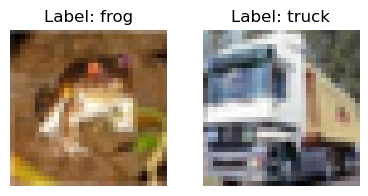

In [ ]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plot two sample images
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

for i, ax in enumerate(axes):
    ax.imshow(train_data.data[i])
    ax.set_title(f"Label: {class_names[train_data.targets[i]]}")
    ax.axis('off')

fig.tight_layout()

## Section 1: Convolution is a weighted filter - It can work as a feature detector

**Exercise**: Run the cell below to create an interactive plot where a vector is convolved with a boxcar. Drag the slider to perform the 1D convolution. The resulting line in the bottom plot is the weighted sum of the original vector and the kernel at that index. When is the result 0 and when is it at its max value?

In [48]:
utils.convolve1d_interactive('boxcar')

interactive(children=(IntSlider(value=10, description='index', max=99, min=10), Output()), _dom_classes=('widg…

**Exercise**: Run the cell below to create an interactive plot where a vector is convolved with a gaussian. Drag the slider to perform the 1D convolution. The resulting line in the bottom plot is the weighted sum of the original vector and the kernel at that index. When is the result 0 and when is it at its max value?

In [ ]:
utils.convolve1d_interactive('gaussian')

interactive(children=(IntSlider(value=10, description='index', max=99, min=10), Output()), _dom_classes=('widg…

**Exercise**: Run the cell below to create an interactive plot where a vector is convolved with a exponential. Drag the slider to perform the 1D convolution. The resulting line in the bottom plot is the weighted sum of the original vector and the kernel at that index. When is the result 0 and when is it at its max value?

In [ ]:
utils.convolve1d_interactive('exponential')

interactive(children=(IntSlider(value=10, description='index', max=99, min=10), Output()), _dom_classes=('widg…

**Exercise**: Run the cell below to create an interactive plot of a 2D convolution.

In [ ]:
utils.convolve2d_horikernel_interactive()

interactive(children=(IntSlider(value=0, description='row', max=31), IntSlider(value=0, description='col', max…

**Exercise**: Run the cell below to create an interactive plot of a 2D convolution.

In [ ]:
utils.convolve2d_vertikernel_interactive()

interactive(children=(IntSlider(value=0, description='row', max=31), IntSlider(value=0, description='col', max…

## Section 2: Convolution Lets Us Reduce the Number of Parameters and Save Computation

One of the main benefits of convolution is that it can reduce the number of parameters that need to be optimized in our model. The underlying assumption is that neighboring features are related; they contain similar information. For example, neighboring pixels in an image are often from the same object in the image. Therefore, we can aggregate the values in neighboring pixels of the image, and this reduces the number of parameters that the need to be trained, which makes training faster.

| Code | Description |
| --- | --- |
| `nn.Conv2d(in_channels, out_channels, kernel_size)` | Creates a 2D convolution to be applied to the signal. |

**Example**: Create a 2D convolution object with 9 in channels, 3 out channels, and a 3x3 kernel.

In [117]:
original_image = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [9.0, 10.0, 11.0, 12.0],
    [13.0, 14.0, 15.0, 16.0]
])-torch.tensor(5.0)

original_image = original_image.unsqueeze(0)

def plot_toy_image(original_image, kernel=None, step=0):

    plt.imshow(original_image[0])
    for i in range(original_image.shape[1]):
        for j in range(original_image.shape[2]):
            plt.text(j, i, f'{int(original_image[0,i, j])}', ha='center', va='center', color='white', fontsize=12)

    if kernel is not None:
        kernel_shape = kernel.weight[0, 0, :].shape
        stride_h, stride_w = kernel.stride
        k_h, k_w = kernel_shape[0], kernel_shape[1]
        img_h, img_w = original_image.shape[1], original_image.shape[2]
        
        # Calculate number of valid positions per row
        positions_per_row = (img_w - k_w) // stride_w + 1
        
        # Calculate row and column based on step
        row = (step // positions_per_row) * stride_h
        col = (step % positions_per_row) * stride_w
        
        rect = plt.Rectangle((col - 0.5, row - 0.5), k_w, k_h, 
                             fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)

In [118]:
conv2d.stride

(2, 2)

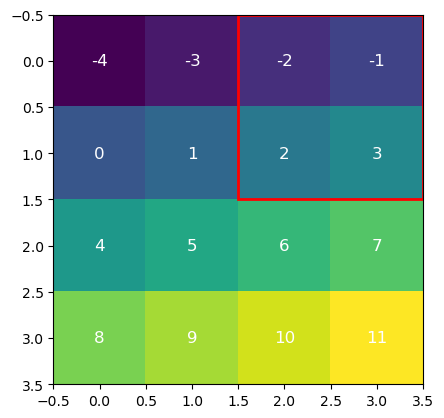

In [120]:
plot_toy_image(original_image, kernel=conv2d, step=1)

In [108]:
conv2d.weight[0,0,:].shape

torch.Size([2, 2])

In [100]:
conv2d = nn.Conv2d(1, 1, (2,2), stride=2, bias=False)

with torch.no_grad(): 
    conv2d.weight[:] = torch.ones_like(conv2d.weight[:])

convolved_image = conv2d(original_image)

convolved_image

tensor([[[-6.,  2.],
         [26., 34.]]], grad_fn=<SqueezeBackward1>)

In [101]:
convolved_image.shape

torch.Size([1, 2, 2])

**Exercise**: Create a 2D convolution object with 8 in channels, 2 out channels, and a 2x2 kernel.

In [ ]:
nn.Conv2d(8,2,(2,2))

Conv2d(8, 2, kernel_size=(2, 2), stride=(1, 1))

## Section 2: What About Image Edges? Padding and Stride

## Section 3 and 4: Application to MNIST (and maybe other standard dataset)